In [1]:
# Column name meanings:
# age        = Age
# sex        = Sex (1 = male, 0 = female)
# cp         = Chest pain type (1–4)
# restBP     = Resting blood pressure (mm Hg)
# chol       = Serum cholesterol (mg/dl)
# fbs        = Fasting blood sugar > 120 mg/dl (1 = true, 0 = false)
# restECG    = Resting electrocardiographic results (0–1)
# max_HR     = Maximum heart rate achieved
# exang      = Exercise induced angina (1 = yes, 0 = no)
# oldpeak    = ST depression induced by exercise
# slope      = Slope of the peak exercise ST segment
# ca         = Number of major vessels (0–3) colored by fluoroscopy
# thal       = Thalassemia (3 = normal, 6 = fixed defect, 7 = reversible defect)
# target     = Diagnosis of heart disease (0 = no,1 = low risk,2= medium risk,3-4= high)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

#loading dataset 
data = pd.read_csv("data/interim/heart_disease_combined.csv")

In [2]:
print("\nFirst 5 rows of the dataset\n")
print(data.head())


First 5 rows of the dataset

    age  sex   cp restBP   chol  fbs restECG max_HR exang oldpeak slope   ca  \
0  63.0  1.0  1.0  145.0  233.0  1.0     2.0  150.0   0.0     2.3   3.0  0.0   
1  67.0  1.0  4.0  160.0  286.0  0.0     2.0  108.0   1.0     1.5   2.0  3.0   
2  67.0  1.0  4.0  120.0  229.0  0.0     2.0  129.0   1.0     2.6   2.0  2.0   
3  37.0  1.0  3.0  130.0  250.0  0.0     0.0  187.0   0.0     3.5   3.0  0.0   
4  41.0  0.0  2.0  130.0  204.0  0.0     2.0  172.0   0.0     1.4   1.0  0.0   

  thal  target  
0  6.0       0  
1  3.0       2  
2  7.0       1  
3  3.0       0  
4  3.0       0  


In [3]:
print("\nData frame shape (rows,column):",data.shape)


Data frame shape (rows,column): (720, 14)


In [4]:
print("\n Data frame information:\n")
print(data.info())


 Data frame information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age      720 non-null    float64
 1   sex      720 non-null    float64
 2   cp       720 non-null    float64
 3   restBP   720 non-null    object 
 4   chol     720 non-null    object 
 5   fbs      720 non-null    object 
 6   restECG  720 non-null    object 
 7   max_HR   720 non-null    object 
 8   exang    720 non-null    object 
 9   oldpeak  720 non-null    object 
 10  slope    720 non-null    object 
 11  ca       720 non-null    object 
 12  thal     720 non-null    object 
 13  target   720 non-null    int64  
dtypes: float64(3), int64(1), object(10)
memory usage: 78.9+ KB
None


In [5]:
#converting "?" to Nan so we don't get any errors
data.replace("?", np.nan, inplace=True)

In [6]:
#converting continuos/numeric data to numeric datatype 
#and categorical data to category datatype

num_cols=["age", "restBP", "chol", "max_HR", "oldpeak"]
cat_cols = ["sex", "cp", "fbs", "restECG", "exang", "slope", "ca", "thal", "target"]
for col in cat_cols:
    data[col] = data[col].astype("category")
for col in num_cols:
    data[col] = data[col].astype("float64")  

In [7]:
#data after editing the data types
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   age      720 non-null    float64 
 1   sex      720 non-null    category
 2   cp       720 non-null    category
 3   restBP   717 non-null    float64 
 4   chol     697 non-null    float64 
 5   fbs      637 non-null    category
 6   restECG  718 non-null    category
 7   max_HR   718 non-null    float64 
 8   exang    718 non-null    category
 9   oldpeak  714 non-null    float64 
 10  slope    513 non-null    category
 11  ca       307 non-null    category
 12  thal     400 non-null    category
 13  target   720 non-null    category
dtypes: category(9), float64(5)
memory usage: 36.5 KB
None


In [8]:
print("\nStatistical summary of numerical feature\n")
print(data.describe())


Statistical summary of numerical feature

              age      restBP        chol      max_HR     oldpeak
count  720.000000  717.000000  697.000000  718.000000  714.000000
mean    51.888889  131.804742  204.774749  140.565460    0.789636
std      9.193720   18.529331  109.275156   25.647172    1.066961
min     28.000000   80.000000    0.000000   60.000000   -2.600000
25%     45.000000  120.000000  182.000000  122.000000    0.000000
50%     53.000000  130.000000  227.000000  142.000000    0.200000
75%     58.000000  140.000000  270.000000  160.000000    1.500000
max     77.000000  200.000000  603.000000  202.000000    6.200000


In [9]:
#minimum cholestrol can't be 0
#ST depression(oldpeak) can't be negative
data['chol'] = data['chol'].replace(0, np.nan)
data['chol'] = data['chol'].fillna(data['chol'].median())

data.loc[data['oldpeak'] < 0, 'oldpeak'] = 0
#updated data
print(data.describe())

              age      restBP        chol      max_HR     oldpeak
count  720.000000  717.000000  720.000000  718.000000  714.000000
mean    51.888889  131.804742  247.406944  140.565460    0.806723
std      9.193720   18.529331   53.428221   25.647172    1.041756
min     28.000000   80.000000   85.000000   60.000000    0.000000
25%     45.000000  120.000000  218.000000  122.000000    0.000000
50%     53.000000  130.000000  242.500000  142.000000    0.200000
75%     58.000000  140.000000  269.000000  160.000000    1.500000
max     77.000000  200.000000  603.000000  202.000000    6.200000


In [10]:
#multiclass (no,low,medium,high)
def risk_level(x):
    if x == 0:
        return 0  # No Risk
    elif x == 1:
        return 1  # Low Risk
    elif x == 2:
        return 2  # Medium Risk
    else:  # 3 or 4
        return 3  # High Risk

data['target_multiclass'] = data['target'].apply(risk_level)

# Binary (0 = No disease, 1 = Disease)
data['target_binary'] = data['target'].apply(lambda x: 0 if x == 0 else 1)

target_counts1= data['target_multiclass'].value_counts()
print("\nDistribution of the target variable:(multiclass)")
print(target_counts1)
target_counts2= data['target_binary'].value_counts()
print("\nDistribution of the target variable:(binary)")
print(target_counts2)


Distribution of the target variable:(multiclass)
target_multiclass
0    360
1    209
3     83
2     68
Name: count, dtype: int64

Distribution of the target variable:(binary)
target_binary
0    360
1    360
Name: count, dtype: int64


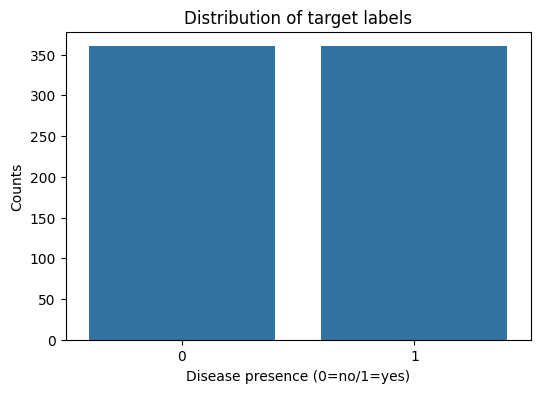

In [11]:
plt.figure(figsize=(6,4))
sns.barplot(x=target_counts2.index,y=target_counts2.values)

plt.title('Distribution of target labels')
plt.xlabel('Disease presence (0=no/1=yes)')
plt.ylabel('Counts')
plt.show()

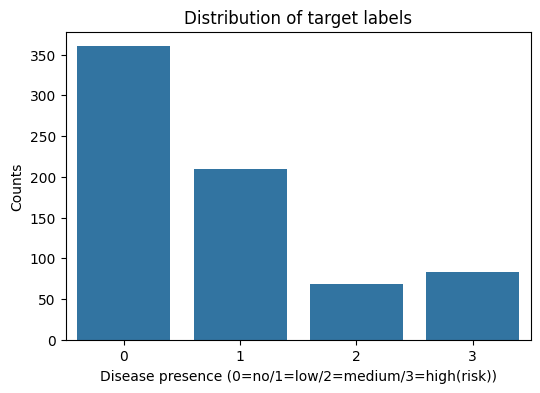

In [12]:
#target distribution
plt.figure(figsize=(6,4))
sns.barplot(x=target_counts1.index,y=target_counts1.values)

plt.title('Distribution of target labels')
plt.xlabel('Disease presence (0=no/1=low/2=medium/3=high(risk))')
plt.ylabel('Counts')
plt.show()

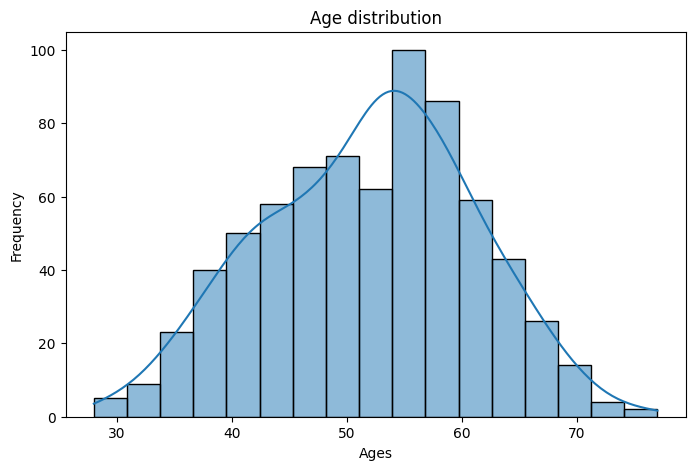

In [13]:
#age distribution
plt.figure(figsize=(8,5))
sns.histplot(data['age'],kde=True)

plt.title('Age distribution')
plt.xlabel('Ages')
plt.ylabel('Frequency')
plt.show()

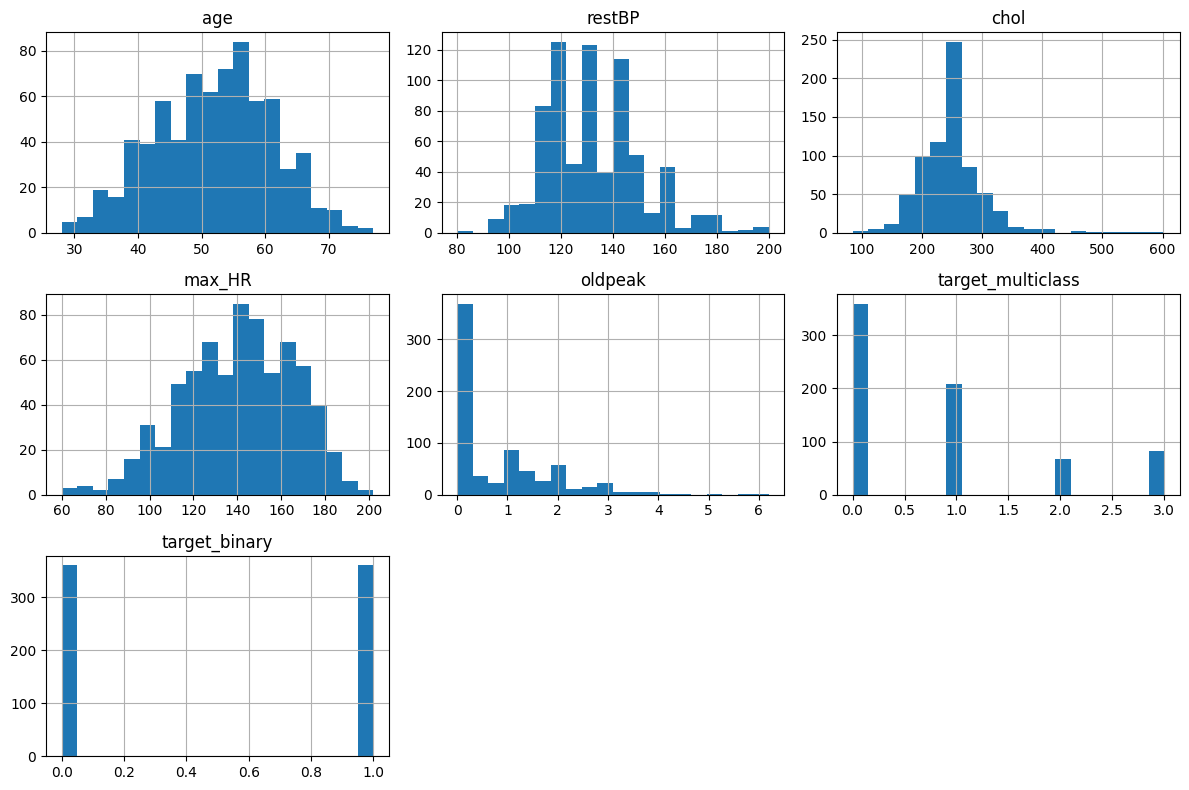

In [14]:
# Select numerical columns
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

# Plot histograms for all numerical columns
data[num_cols].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

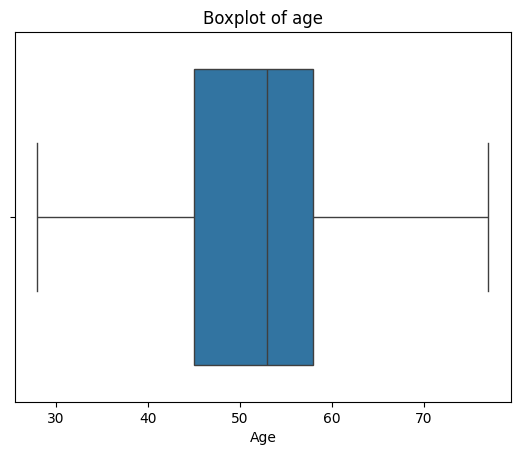

In [15]:
#box graph for age
#vertical line inside the box shows median
sns.boxplot(x=data['age'])
plt.title('Boxplot of age')
plt.xlabel('Age')
plt.show()

In [16]:
# Drop the original 'target' column
#now we have 2 target columns
data = data.drop(columns=['target'])

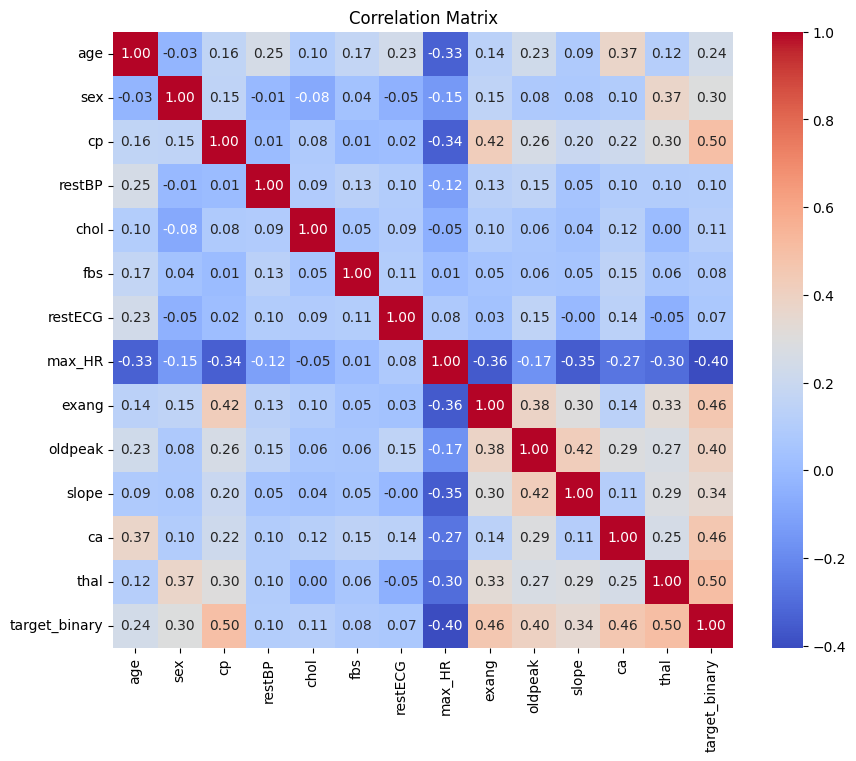

In [17]:
#dropping target_multiclass for correlation matrix
data_corr = data.drop(columns=['target_multiclass'])  

correlation_matrix= data_corr.corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True,cmap="coolwarm",fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

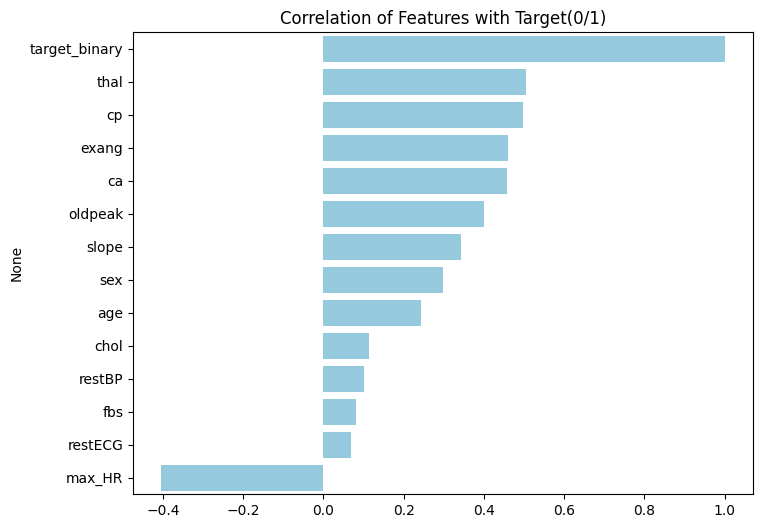

In [18]:
corr_with_target = correlation_matrix["target_binary"].sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index,color="skyblue")
plt.title("Correlation of Features with Target(0/1)")
plt.show()

In [19]:
#missing values check
missing=data.isnull().sum()
print("Missing values per column:")
print(missing)

Missing values per column:
age                    0
sex                    0
cp                     0
restBP                 3
chol                   0
fbs                   83
restECG                2
max_HR                 2
exang                  2
oldpeak                6
slope                207
ca                   413
thal                 320
target_multiclass      0
target_binary          0
dtype: int64


In [20]:
#using median imputation for the numeric continuous data
median_cols = [ "restBP", "chol", "max_HR", "oldpeak"]
for col in median_cols:
    data[col]=data[col].fillna(data[col].median())

#using mode imputation for categorical discrete data
mode_cols = ["fbs", "restECG", "exang", "slope", "ca", "thal"]
for col in mode_cols:
    data[col] = data[col].fillna(data[col].mode()[0])#[0]incase of multiple modes first one is assigned

In [21]:
#missing values after imputation
missing=data.isnull().sum()
print("Missing values per column:")
print(missing)

Missing values per column:
age                  0
sex                  0
cp                   0
restBP               0
chol                 0
fbs                  0
restECG              0
max_HR               0
exang                0
oldpeak              0
slope                0
ca                   0
thal                 0
target_multiclass    0
target_binary        0
dtype: int64


In [22]:
# Outlier detection (IQR method)
num_cols=["age", "restBP", "chol", "max_HR", "oldpeak"]

Q1 = data[num_cols].quantile(0.25)
Q3 = data[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = ((data[num_cols] < (lower_bound)) | (data[num_cols] > (upper_bound)))

print("Outliers detected per column:\n")
print(outlier_mask.sum())

Outliers detected per column:

age         0
restBP     22
chol       32
max_HR      2
oldpeak    11
dtype: int64


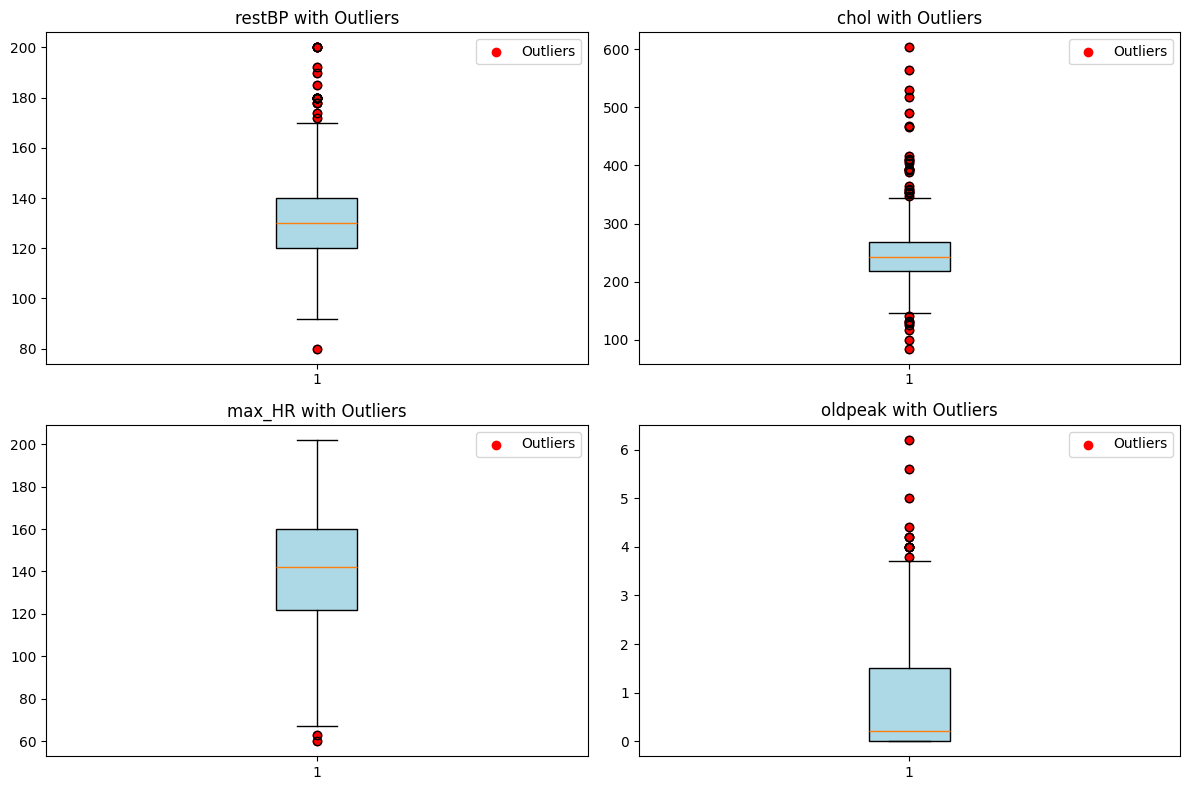

In [24]:
# Columns with outliers
cols_with_outliers = outlier_mask.sum()[outlier_mask.sum() > 0].index

# Create a 2x2 grid for plotting
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), cols_with_outliers):
    # Boxplot
    ax.boxplot(data[col], patch_artist=True, boxprops=dict(facecolor='lightblue'))
    
    # Highlight outliers
    outliers = data[col][outlier_mask[col]]
    ax.scatter([1]*len(outliers), outliers, color='red', label='Outliers')
    
    ax.set_title(f'{col} with Outliers')
    ax.legend()

plt.tight_layout()
plt.show()


In [25]:
def cap_outliers_iqr(df, cols):
    for col in cols:
        df[col] = np.clip(df[col], lower_bound[col], upper_bound[col])
    return df

# Apply capping
data = cap_outliers_iqr(data, num_cols)
# Check result
print(data[num_cols].describe())

              age      restBP        chol      max_HR     oldpeak
count  720.000000  720.000000  720.000000  720.000000  720.000000
mean    51.888889  131.395833  245.076389  140.579167    0.790347
std      9.193720   17.335926   43.851537   25.582056    0.997745
min     28.000000   90.000000  141.500000   65.000000    0.000000
25%     45.000000  120.000000  218.000000  122.000000    0.000000
50%     53.000000  130.000000  242.500000  142.000000    0.200000
75%     58.000000  140.000000  269.000000  160.000000    1.500000
max     77.000000  170.000000  345.500000  202.000000    3.750000


In [26]:
print("Data (rows,columns)after cleaning/imputations")
print(data.shape)

Data (rows,columns)after cleaning/imputations
(720, 15)


In [27]:
#create a new .csv file with cleaned data
data.to_csv("data/interim/cleaned_heart_dataset.csv",index=False)